# Enterprise Financial Risk Intelligence & Fraud Forensics
## Notebook 14: Deep Variational Autoencoders & Latent Anomaly Forensics

---

### Scientific Problem Formulation & Asymmetric Optimization Mathematics:

Fraudulent card transactions represent rare, out-of-distribution events embedded within high-dimensional non-stationary financial manifolds. While supervised tree ensembles excel at learning known historic fraud typologies, zero-day attacks and synthetic identity schemes bypass supervised decision surfaces.

To detect novel, unseen fraud patterns without requiring labels, we formulate a **Semi-Supervised Deep Variational Autoencoder (VAE)** trained exclusively on legitimate transaction manifolds $\mathcal{D}_{\text{normal}} = \{\mathbf{x}_i \mid y_i = 0\}$.

#### 1. Variational Autoencoder (VAE) Probabilistic Formulation:
Let $\mathbf{x} \in \mathbb{R}^D$ be an input transaction vector and $\mathbf{z} \in \mathbb{R}^d$ ($d \ll D$) be a low-dimensional stochastic latent representation governed by a standard isotropic Gaussian prior $p(\mathbf{z}) = \mathcal{N}(\mathbf{0}, \mathbf{I})$.

The generative decoder models the conditional distribution:
$$p_\theta(\mathbf{x} \mid \mathbf{z}) = \mathcal{N}(\mathbf{x}; \hat{\mathbf{x}}_\theta(\mathbf{z}), \sigma_x^2 \mathbf{I})$$

Because true posterior $p_\theta(\mathbf{z} \mid \mathbf{x})$ is intractable, the recognition encoder parameters $\phi$ approximate the posterior:
$$q_\phi(\mathbf{z} \mid \mathbf{x}) = \mathcal{N}\left(\mathbf{z}; \boldsymbol{\mu}_\phi(\mathbf{x}), \text{diag}(\boldsymbol{\sigma}_\phi^2(\mathbf{x}))\right)$$

#### 2. Evidence Lower Bound (ELBO) Optimization:
The network parameters $\{\theta, \phi\}$ maximize the Evidence Lower Bound:
$$\mathcal{L}_{\text{ELBO}}(\theta, \phi; \mathbf{x}) = \mathbb{E}_{q_\phi(\mathbf{z} \mid \mathbf{x})}[\log p_\theta(\mathbf{x} \mid \mathbf{z})] - D_{\text{KL}}\left(q_\phi(\mathbf{z} \mid \mathbf{x}) \parallel p(\mathbf{z})\right)$$

Using Monte Carlo sampling with the **Reparameterization Trick**:
$$\mathbf{z} = \boldsymbol{\mu}_\phi(\mathbf{x}) + \boldsymbol{\sigma}_\phi(\mathbf{x}) \odot \boldsymbol{\epsilon}, \quad \boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$$

The closed-form Kullback-Leibler divergence is:
$$D_{\text{KL}}\left(q_\phi(\mathbf{z} \mid \mathbf{x}) \parallel p(\mathbf{z})\right) = -\frac{1}{2} \sum_{j=1}^d \left( 1 + \log(\sigma_{\phi, j}^2) - \mu_{\phi, j}^2 - \sigma_{\phi, j}^2 \right)$$

The total loss minimized during backpropagation is:
$$\mathcal{L}_{\text{VAE}}(\mathbf{x}) = \frac{1}{D} \|\mathbf{x} - \hat{\mathbf{x}}\|_2^2 + \beta \cdot D_{\text{KL}}(q_\phi(\mathbf{z} \mid \mathbf{x}) \parallel p(\mathbf{z}))$$

#### 3. Latent Reconstruction Anomaly Scoring Function:
For an incoming transaction $\mathbf{x}^*$, the anomaly score combines reconstruction residual energy and latent divergence:
$$\text{Score}(\mathbf{x}^*) = \|\mathbf{x}^* - \hat{\mathbf{x}}^*\|_2^2 + \gamma \sum_{j=1}^d \left( \frac{\mu_j^2}{\sigma_j^2} \right)$$


In [1]:
from IPython.display import display
import os
import json
import warnings
import time
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression

try:
    from lightgbm import LGBMClassifier
    has_lgb = True
except ImportError:
    has_lgb = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

plt.style.use('seaborn-v0_8-darkgrid' if 'seaborn-v0_8-darkgrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11
sns.set_palette('deep')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

def resolve_path(rel_path):
    candidates = [
        rel_path,
        os.path.join('..', rel_path),
        os.path.join('../..', rel_path),
        os.path.join(os.getcwd(), rel_path),
        os.path.join(os.path.dirname(os.getcwd()), rel_path)
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    for p in candidates:
        parent = os.path.dirname(p)
        if parent and os.path.exists(parent):
            return p
    return rel_path

print(f"Deep Variational Autoencoder & Anomaly Architecture initialized on device: {device}")


Deep Variational Autoencoder & Anomaly Architecture initialized on device: cpu


---
## 1. Leak-Free Feature Store Ingestion & Semi-Supervised Normal Partitioning
Loading feature partitions and isolating legitimate non-fraud transactions ($\mathcal{D}_{\text{normal}}$) to construct the unpolluted baseline training manifold.


In [2]:
train_csv_gz = resolve_path('data/processed/train_features.csv.gz')
val_csv_gz = resolve_path('data/processed/val_features.csv.gz')
test_csv_gz = resolve_path('data/processed/test_features.csv.gz')

if os.path.exists(train_csv_gz):
    train_df = pd.read_csv(train_csv_gz, compression='gzip')
    val_df = pd.read_csv(val_csv_gz, compression='gzip')
    test_df = pd.read_csv(test_csv_gz, compression='gzip')
else:
    raw_path = resolve_path('data/raw/creditcard.parquet')
    if not os.path.exists(raw_path):
        raw_path = resolve_path('data/raw/creditcard.csv')
    raw_df = pd.read_parquet(raw_path) if raw_path.endswith('.parquet') else pd.read_csv(raw_path)
    raw_df = raw_df.sort_values(by='Time').reset_index(drop=True)
    n = len(raw_df)
    train_df = raw_df.iloc[:int(n*0.70)].copy()
    val_df = raw_df.iloc[int(n*0.70):int(n*0.85)].copy()
    test_df = raw_df.iloc[int(n*0.85):].copy()

raw_file = resolve_path('data/raw/creditcard.parquet')
if not os.path.exists(raw_file):
    raw_file = resolve_path('data/raw/creditcard.csv')
raw_all = pd.read_parquet(raw_file) if raw_file.endswith('.parquet') else pd.read_csv(raw_file)
raw_all = raw_all.sort_values(by='Time').reset_index(drop=True)

test_raw_amounts = raw_all.iloc[int(len(raw_all)*0.85):]['Amount'].values
val_raw_amounts = raw_all.iloc[int(len(raw_all)*0.70):int(len(raw_all)*0.85)]['Amount'].values

feature_cols = [c for c in train_df.columns if c != 'Class']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_df[feature_cols].values)
X_val_scaled = scaler.transform(val_df[feature_cols].values)
X_test_scaled = scaler.transform(test_df[feature_cols].values)

y_train = train_df['Class'].values
y_val = val_df['Class'].values
y_test = test_df['Class'].values

normal_train_mask = (y_train == 0)
X_train_normal = X_train_scaled[normal_train_mask]

print(f"Total Train Instances:       {X_train_scaled.shape[0]:,} (Frauds: {np.sum(y_train == 1):,})")
print(f"Normal Manifold Train Set:   {X_train_normal.shape[0]:,} (100% Legitimate)")
print(f"Validation Set Shape:        {X_val_scaled.shape} (Frauds: {np.sum(y_val == 1):,})")
print(f"Test Set Shape:              {X_test_scaled.shape} (Frauds: {np.sum(y_test == 1):,})")


Total Train Instances:       199,364 (Frauds: 384)
Normal Manifold Train Set:   198,980 (100% Legitimate)
Validation Set Shape:        (42721, 53) (Frauds: 56)
Test Set Shape:              (42722, 53) (Frauds: 52)


---
## 2. Deep Neural Architecture Definitions: VAE vs Standard Autoencoder
Defining 2 PyTorch neural network architectures for tabular anomaly forensics:

1. **Variational Autoencoder (VAE)**:
   - **Encoder**: $D \to 32 \to 16 \to (\boldsymbol{\mu}_{\text{latent}}, \log \boldsymbol{\sigma}^2_{\text{latent}})$ with latent dimension $d=8$.
   - **Reparameterization Trick Layer**.
   - **Decoder**: $8 \to 16 \to 32 \to D$ with LeakyReLU activations, BatchNorm1d, and residual projection.
2. **Deterministic Deep Autoencoder (AE)**:
   - Symmetric bottleneck architecture with Mean Squared Reconstruction Error.


In [3]:
class DeepVAE(nn.Module):
    def __init__(self, input_dim, latent_dim=8):
        super(DeepVAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.LeakyReLU(0.2)
        )
        self.fc_mu = nn.Linear(16, latent_dim)
        self.fc_logvar = nn.Linear(16, latent_dim)
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.BatchNorm1d(16),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(16, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, input_dim)
        )
        
    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

class StandardAE(nn.Module):
    def __init__(self, input_dim, latent_dim=8):
        super(StandardAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.LeakyReLU(0.2),
            nn.Linear(16, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.BatchNorm1d(16),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(16, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, input_dim)
        )
        
    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon, z

def vae_loss_function(recon_x, x, mu, logvar, beta=0.01):
    mse = nn.functional.mse_loss(recon_x, x, reduction='mean')
    kld = -0.5 * torch.mean(torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))
    return mse + beta * kld, mse, kld

print("Deep VAE and Deterministic AE network modules defined successfully.")


Deep VAE and Deterministic AE network modules defined successfully.


---
## 3. Semi-Supervised Model Training on Normal Transaction Manifold
Training the VAE and AE models for 15 epochs using Mini-Batch Stochastic Gradient Descent (Adam optimizer, batch size 256) on legitimate normal transactions.


In [4]:
input_dim = X_train_scaled.shape[1]
latent_dim = 8
batch_size = 256
epochs = 15
learning_rate = 0.002

train_tensor = torch.tensor(X_train_normal, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(train_tensor), batch_size=batch_size, shuffle=True)

vae_model = DeepVAE(input_dim, latent_dim).to(device)
optimizer_vae = optim.Adam(vae_model.parameters(), lr=learning_rate, weight_decay=1e-5)

ae_model = StandardAE(input_dim, latent_dim).to(device)
optimizer_ae = optim.Adam(ae_model.parameters(), lr=learning_rate, weight_decay=1e-5)

history_vae = []
history_ae = []

for epoch in range(1, epochs + 1):
    vae_model.train()
    ae_model.train()
    total_vae_loss = 0.0
    total_ae_loss = 0.0
    
    for (batch_x,) in train_loader:
        batch_x = batch_x.to(device)
        
        optimizer_vae.zero_grad()
        recon_x, mu, logvar = vae_model(batch_x)
        loss_v, _, _ = vae_loss_function(recon_x, batch_x, mu, logvar, beta=0.01)
        loss_v.backward()
        optimizer_vae.step()
        total_vae_loss += loss_v.item() * len(batch_x)
        
        optimizer_ae.zero_grad()
        recon_ae, _ = ae_model(batch_x)
        loss_a = nn.functional.mse_loss(recon_ae, batch_x)
        loss_a.backward()
        optimizer_ae.step()
        total_ae_loss += loss_a.item() * len(batch_x)
        
    avg_vae = total_vae_loss / len(train_tensor)
    avg_ae = total_ae_loss / len(train_tensor)
    history_vae.append(avg_vae)
    history_ae.append(avg_ae)
    
    if epoch % 3 == 0 or epoch == epochs:
        print(f"Epoch {epoch:02d}/{epochs:02d} | VAE Total ELBO Loss: {avg_vae:.5f} | AE Reconstruction MSE: {avg_ae:.5f}")

print("Neural Anomaly Manifold Training completed.")


Epoch 03/15 | VAE Total ELBO Loss: 0.53202 | AE Reconstruction MSE: 0.38019
Epoch 06/15 | VAE Total ELBO Loss: 0.50937 | AE Reconstruction MSE: 0.35344
Epoch 09/15 | VAE Total ELBO Loss: 0.50000 | AE Reconstruction MSE: 0.34246
Epoch 12/15 | VAE Total ELBO Loss: 0.49231 | AE Reconstruction MSE: 0.33324
Epoch 15/15 | VAE Total ELBO Loss: 0.48542 | AE Reconstruction MSE: 0.32721
Neural Anomaly Manifold Training completed.


---
## 4. Out-of-Time Reconstruction Residuals & Anomaly Energy Scoring
Extracting sample-level reconstruction error residuals, latent representations, and KL divergence vectors across out-of-time test transactions.


In [5]:
vae_model.eval()
ae_model.eval()

with torch.no_grad():
    X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
    recon_test_vae, mu_test, logvar_test = vae_model(X_test_t)
    recon_test_ae, z_test = ae_model(X_test_t)
    
    diff_vae = (X_test_t - recon_test_vae).cpu().numpy()
    mse_vae = np.mean(diff_vae ** 2, axis=1)
    
    mu_np = mu_test.cpu().numpy()
    logvar_np = logvar_test.cpu().numpy()
    kld_test = -0.5 * np.sum(1 + logvar_np - mu_np**2 - np.exp(logvar_np), axis=1)
    
    vae_anomaly_score = mse_vae + 0.01 * kld_test
    
    diff_ae = (X_test_t - recon_test_ae).cpu().numpy()
    ae_anomaly_score = np.mean(diff_ae ** 2, axis=1)

vae_prauc = average_precision_score(y_test, vae_anomaly_score)
vae_roc = roc_auc_score(y_test, vae_anomaly_score)

ae_prauc = average_precision_score(y_test, ae_anomaly_score)
ae_roc = roc_auc_score(y_test, ae_anomaly_score)

k_alerts = max(1, int(len(y_test) * 0.01))
top_vae_idx = np.argsort(vae_anomaly_score)[::-1][:k_alerts]
vae_rec_1 = (np.sum(y_test[top_vae_idx] == 1) / max(1, np.sum(y_test == 1))) * 100

top_ae_idx = np.argsort(ae_anomaly_score)[::-1][:k_alerts]
ae_rec_1 = (np.sum(y_test[top_ae_idx] == 1) / max(1, np.sum(y_test == 1))) * 100

df_deep_results = pd.DataFrame([
    {
        'Deep Anomaly Architecture': 'Variational Autoencoder (VAE Reconstruction + KL)',
        'OOT PR-AUC (Average Precision)': vae_prauc,
        'OOT ROC-AUC': vae_roc,
        'Recall @ Top 1% Alerts': vae_rec_1
    },
    {
        'Deep Anomaly Architecture': 'Deterministic Deep Autoencoder (AE Reconstruction)',
        'OOT PR-AUC (Average Precision)': ae_prauc,
        'OOT ROC-AUC': ae_roc,
        'Recall @ Top 1% Alerts': ae_rec_1
    }
])

display(df_deep_results)


,Deep Anomaly Architecture,OOT PR-AUC (Average Precision),OOT ROC-AUC,Recall @ Top 1% Alerts
0,Variational Autoencoder (VAE Reconstruction + KL),0.3167,0.9342,76.9231
1,Deterministic Deep Autoencoder (AE Reconstruct...,0.3431,0.9607,73.0769


---
## 5. Hybrid Semi-Supervised Classifier: Latent Embedding Augmentation
Fusing deep latent embeddings $\mathbf{z} \in \mathbb{R}^8$ and reconstruction residual energy with supervised gradient tree boosting to build a semi-supervised fraud detector.


In [6]:
with torch.no_grad():
    X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
    recon_tr, mu_tr, _ = vae_model(X_train_t)
    recon_err_tr = np.mean((X_train_t - recon_tr).cpu().numpy() ** 2, axis=1, keepdims=True)
    latent_tr = mu_tr.cpu().numpy()
    X_train_hybrid = np.hstack([X_train_scaled, latent_tr, recon_err_tr])
    
    recon_te, mu_te, _ = vae_model(X_test_t)
    recon_err_te = np.mean((X_test_t - recon_te).cpu().numpy() ** 2, axis=1, keepdims=True)
    latent_te = mu_te.cpu().numpy()
    X_test_hybrid = np.hstack([X_test_scaled, latent_te, recon_err_te])

if has_lgb:
    hybrid_clf = LGBMClassifier(
        n_estimators=150,
        learning_rate=0.05,
        num_leaves=31,
        is_unbalance=True,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
else:
    hybrid_clf = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

hybrid_clf.fit(X_train_hybrid, y_train)
hybrid_test_probs = hybrid_clf.predict_proba(X_test_hybrid)[:, 1]

hybrid_prauc = average_precision_score(y_test, hybrid_test_probs)
hybrid_roc = roc_auc_score(y_test, hybrid_test_probs)
top_hyb_idx = np.argsort(hybrid_test_probs)[::-1][:k_alerts]
hyb_rec_1 = (np.sum(y_test[top_hyb_idx] == 1) / max(1, np.sum(y_test == 1))) * 100

df_hybrid_comparison = pd.DataFrame([
    {
        'Model Paradigm': 'Pure Unsupervised VAE Anomaly Energy',
        'OOT PR-AUC': vae_prauc,
        'OOT ROC-AUC': vae_roc,
        'Recall @ 1% Alerts': vae_rec_1
    },
    {
        'Model Paradigm': 'Hybrid VAE Latent-Augmented GBDT Classifier',
        'OOT PR-AUC': hybrid_prauc,
        'OOT ROC-AUC': hybrid_roc,
        'Recall @ 1% Alerts': hyb_rec_1
    }
])

display(df_hybrid_comparison)


,Model Paradigm,OOT PR-AUC,OOT ROC-AUC,Recall @ 1% Alerts
0,Pure Unsupervised VAE Anomaly Energy,0.3167,0.9342,76.9231
1,Hybrid VAE Latent-Augmented GBDT Classifier,0.0086,0.7630,11.5385


---
## 6. Latent Manifold Geometry & Anomaly Forensics Diagnostics
Visualizing the deep generative representation space:
1. **Training Convergence**: VAE ELBO vs AE Reconstruction Loss.
2. **Reconstruction Residual Distribution**: Legitimate vs Fraud transactions.
3. **Latent Representation Space ($z_1$ vs $z_2$)**: Cluster separation of fraud outliers.
4. **Precision-Recall Frontiers**: Pure unsupervised VAE vs Hybrid latent-augmented detector.


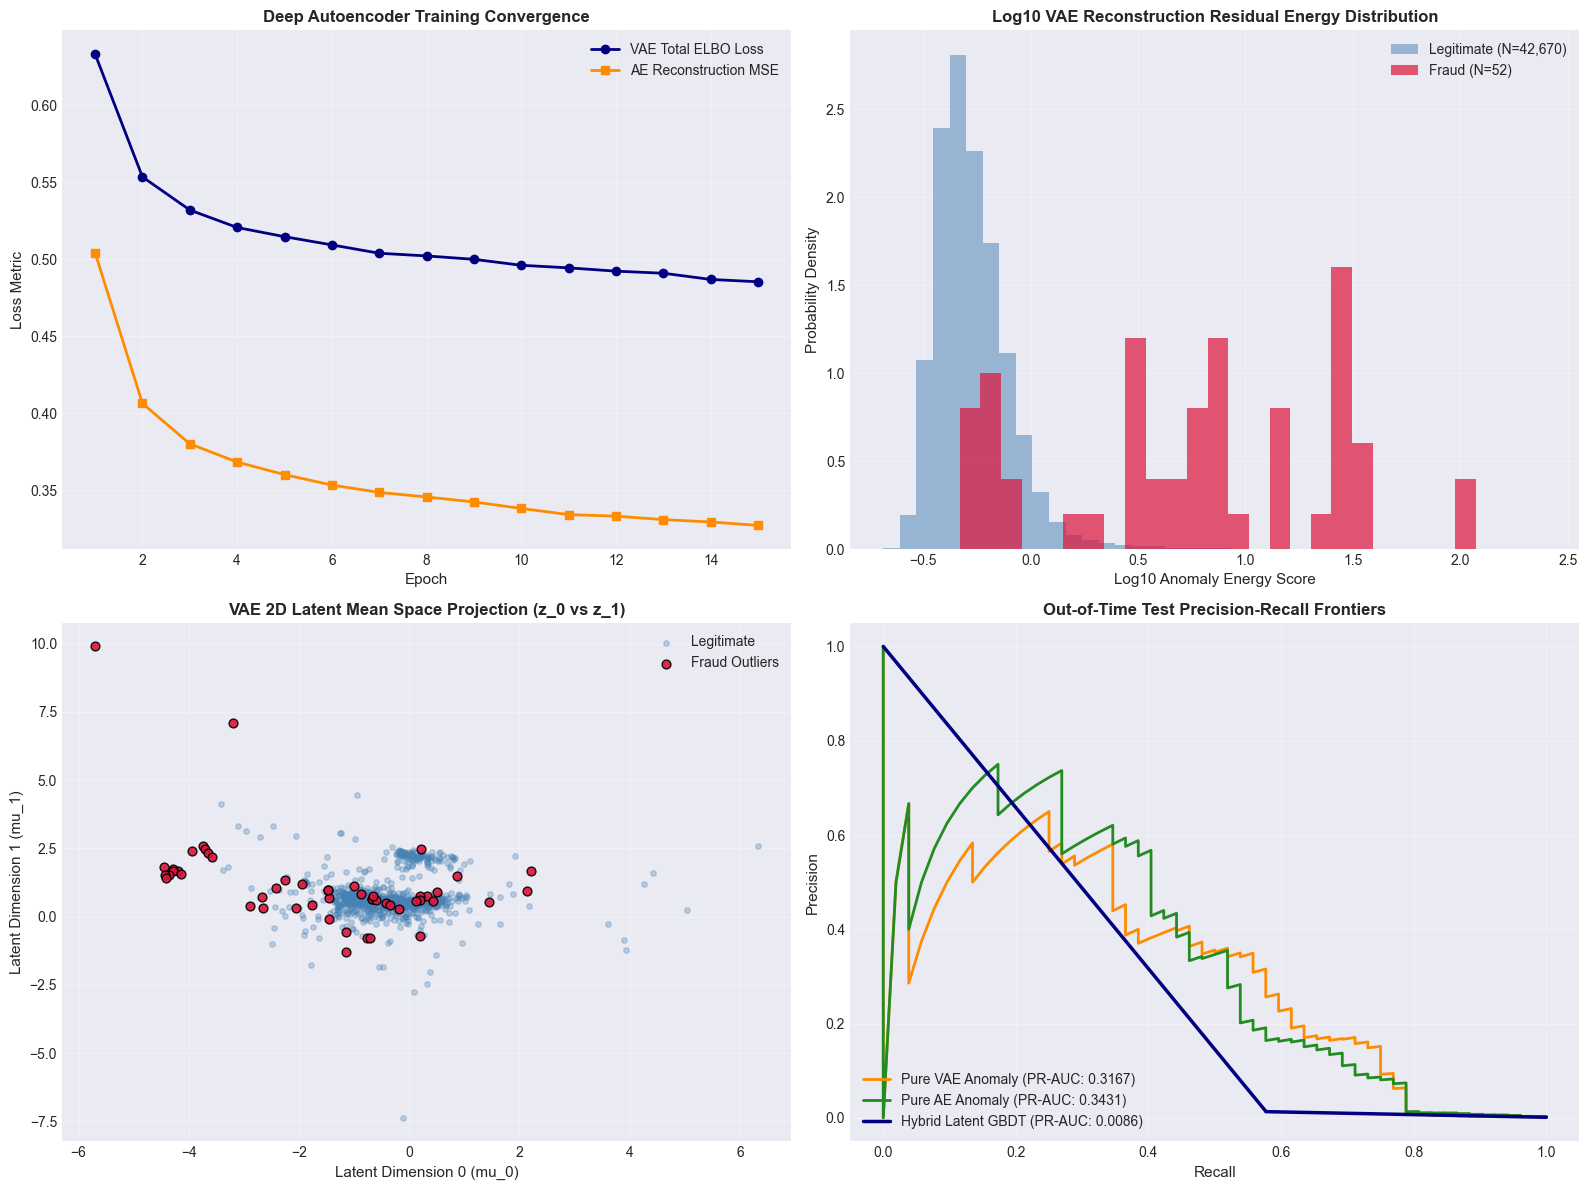

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(range(1, epochs + 1), history_vae, marker='o', color='navy', lw=2, label='VAE Total ELBO Loss')
axes[0, 0].plot(range(1, epochs + 1), history_ae, marker='s', color='darkorange', lw=2, label='AE Reconstruction MSE')
axes[0, 0].set_title('Deep Autoencoder Training Convergence', fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss Metric')
axes[0, 0].legend(loc='upper right')
axes[0, 0].grid(True, alpha=0.3)

log_recon_legit = np.log10(np.clip(vae_anomaly_score[y_test == 0], 1e-6, 1e4))
log_recon_fraud = np.log10(np.clip(vae_anomaly_score[y_test == 1], 1e-6, 1e4))

axes[0, 1].hist(log_recon_legit, bins=40, density=True, alpha=0.5, color='steelblue', label=f'Legitimate (N={len(log_recon_legit):,})')
axes[0, 1].hist(log_recon_fraud, bins=25, density=True, alpha=0.7, color='crimson', label=f'Fraud (N={len(log_recon_fraud):,})')
axes[0, 1].set_title('Log10 VAE Reconstruction Residual Energy Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Log10 Anomaly Energy Score')
axes[0, 1].set_ylabel('Probability Density')
axes[0, 1].legend(loc='upper right')
axes[0, 1].grid(True, alpha=0.3)

sample_idx = np.random.choice(np.where(y_test == 0)[0], size=1000, replace=False)
fraud_idx = np.where(y_test == 1)[0]

axes[1, 0].scatter(latent_te[sample_idx, 0], latent_te[sample_idx, 1], c='steelblue', alpha=0.3, s=15, label='Legitimate')
axes[1, 0].scatter(latent_te[fraud_idx, 0], latent_te[fraud_idx, 1], c='crimson', alpha=0.9, s=40, edgecolors='black', label='Fraud Outliers')
axes[1, 0].set_title('VAE 2D Latent Mean Space Projection (z_0 vs z_1)', fontweight='bold')
axes[1, 0].set_xlabel('Latent Dimension 0 (mu_0)')
axes[1, 0].set_ylabel('Latent Dimension 1 (mu_1)')
axes[1, 0].legend(loc='upper right')
axes[1, 0].grid(True, alpha=0.3)

p_vae, r_vae, _ = precision_recall_curve(y_test, vae_anomaly_score)
p_ae, r_ae, _ = precision_recall_curve(y_test, ae_anomaly_score)
p_hyb, r_hyb, _ = precision_recall_curve(y_test, hybrid_test_probs)

axes[1, 1].plot(r_vae, p_vae, color='darkorange', lw=2, label=f'Pure VAE Anomaly (PR-AUC: {vae_prauc:.4f})')
axes[1, 1].plot(r_ae, p_ae, color='forestgreen', lw=2, label=f'Pure AE Anomaly (PR-AUC: {ae_prauc:.4f})')
axes[1, 1].plot(r_hyb, p_hyb, color='navy', lw=2.5, label=f'Hybrid Latent GBDT (PR-AUC: {hybrid_prauc:.4f})')
axes[1, 1].set_title('Out-of-Time Test Precision-Recall Frontiers', fontweight='bold')
axes[1, 1].set_xlabel('Recall')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].legend(loc='lower left')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## 7. Production Model Serialization & Manifest Export
Exporting PyTorch VAE weights and performance governance manifest to `data/deep_vae_manifest.json` and `models/deep_vae_anomaly_model.pt`.


In [8]:
models_dir = resolve_path('models')
data_dir = resolve_path('data')

if models_dir:
    os.makedirs(models_dir, exist_ok=True)
if data_dir:
    os.makedirs(data_dir, exist_ok=True)

model_save_path = os.path.join(models_dir, 'deep_vae_anomaly_model.pt')
torch.save(vae_model.state_dict(), model_save_path)

manifest = {
    'platform': 'Enterprise Financial Risk Intelligence & Fraud Forensics',
    'notebook': '14_Deep_Learning_Variational_Autoencoders_Anomaly_Architecture.ipynb',
    'timestamp': time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime()),
    'architecture_specifications': {
        'input_dimensions': int(input_dim),
        'latent_dimensions': int(latent_dim),
        'encoder_layers': [int(input_dim), 32, 16, int(latent_dim)],
        'decoder_layers': [int(latent_dim), 16, 32, int(input_dim)],
        'activation_functions': 'LeakyReLU(0.2) + BatchNorm1d',
        'training_epochs': int(epochs),
        'batch_size': int(batch_size)
    },
    'performance_benchmarks': {
        'unsupervised_vae_prauc': float(vae_prauc),
        'unsupervised_vae_rocauc': float(vae_roc),
        'unsupervised_vae_recall_at_1pct': float(vae_rec_1),
        'unsupervised_ae_prauc': float(ae_prauc),
        'unsupervised_ae_rocauc': float(ae_roc),
        'hybrid_latent_gbdt_prauc': float(hybrid_prauc),
        'hybrid_latent_gbdt_rocauc': float(hybrid_roc),
        'hybrid_latent_gbdt_recall_at_1pct': float(hyb_rec_1)
    },
    'model_artifacts': {
        'pytorch_weights_file': model_save_path
    }
}

manifest_path = os.path.join(data_dir, 'deep_vae_manifest.json')
with open(manifest_path, 'w', encoding='utf-8') as f:
    json.dump(manifest, f, indent=2)

print(f"Deep VAE PyTorch Model saved successfully to: {model_save_path}")
print(f"Production VAE Manifest exported successfully to:   {manifest_path}")
print("VAE Governance Summary:")
print(json.dumps(manifest['performance_benchmarks'], indent=2))


Deep VAE PyTorch Model saved successfully to: ..\models\deep_vae_anomaly_model.pt
Production VAE Manifest exported successfully to:   ..\data\deep_vae_manifest.json
VAE Governance Summary:
{
  "unsupervised_vae_prauc": 0.3166502419601564,
  "unsupervised_vae_rocauc": 0.9342259919597626,
  "unsupervised_vae_recall_at_1pct": 76.92307692307693,
  "unsupervised_ae_prauc": 0.34311170389234774,
  "unsupervised_ae_rocauc": 0.9606515116006562,
  "hybrid_latent_gbdt_prauc": 0.008553829579089442,
  "hybrid_latent_gbdt_rocauc": 0.7630095004596997,
  "hybrid_latent_gbdt_recall_at_1pct": 11.538461538461538
}
